# 10-3 트랜스포머의 변형 - 디코더만 사용하는 트랜스포머

본 노트북은 10-3절 본문 예제 [코드 10-9]~[코드 10-12]를 모아 위에서 아래로
실행해 본다. 인과 마스크를 적용한 `nn.TransformerEncoder`로 디코더만
사용하는 트랜스포머를 만들어, 7장 오즈의 소설가 모델(모델 9)을 트랜스포머로
재구현한 `OzWriterTransformer` 모델을 학습한다. 이어서 탐욕 디코딩, 온도
샘플링, 빔 서치 세 가지 추론 방법을 비교한다.

다루는 내용
- 디코더만 사용하는 트랜스포머 `OzWriterTransformer` 클래스 ([코드 10-9])
- 탐욕 디코딩 생성 함수 ([코드 10-10])
- 온도 샘플링 생성 함수 ([코드 10-11])
- 빔 서치 생성 함수 ([코드 10-12])

오즈의 마법사 텍스트 로딩/토큰화, 비중첩 분할 데이터셋, 학습 함수는
노트북에서 직접 정의한다. 위치 인코딩은 10-1절 [코드 10-1]과 동일하다.

In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# 10장 예제는 PyTorch 기본 패키지만으로 동작한다.
# !pip install -q matplotlib numpy torch

In [2]:
# 참고 - 공통 라이브러리 경로 설정
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

viz.configure(save_grayscale=False)

In [3]:
# 참고 - 라이브러리 import 와 시드 고정
SEED = 42
common.set_seed(SEED)
device = common.get_device()

CUDA를 사용합니다.


## 오즈의 마법사 텍스트 로딩 및 전처리

`data/wonderful_wizard_of_oz.txt`에서 본문(Chapter I 이후)을 추출하고,
7-2절과 같은 방식으로 단어 단위로 토큰화한다.

In [4]:
from pathlib import Path
import re

# 참고 - 오즈의 마법사 텍스트 로딩 (utf-8-sig + Chapter I 본문 추출)
raw = Path('../../data/wonderful_wizard_of_oz.txt').read_text(
    encoding='utf-8-sig',
)
match = re.search(r'\nChapter I\n', raw)
start = match.start() if match else raw.find('Chapter I')
end = raw.rfind('*** END OF THE PROJECT GUTENBERG')
if end == -1:
    end = raw.rfind('THE END')
text = raw[start:end].strip()

# 토큰화 (7-2 절과 동일)
normalized = text.lower()
normalized = re.sub(r'[^a-z\s,.!?\u2019\']', ' ', normalized)
tokens = re.findall(r"[a-z\u2019']+|[,.!?]", normalized)
tokens = [t.rstrip('\u2019') if not t.endswith("'") else t for t in tokens]
tokens = [t for t in tokens if t]
print(f'전체 토큰 수: {len(tokens):,}')
print(f'고유 토큰 수: {len(set(tokens)):,}')
print(f'처음 20 토큰: {tokens[:20]}')

전체 토큰 수: 44,299
고유 토큰 수: 2,902
처음 20 토큰: ['chapter', 'i', 'the', 'cyclone', 'dorothy', 'lived', 'in', 'the', 'midst', 'of', 'the', 'great', 'kansas', 'prairies', ',', 'with', 'uncle', 'henry', ',', 'who']


## 어휘 사전과 데이터셋 (고정 길이 비중첩 분할)

전체 텍스트를 길이 `SEQ_LENGTH + 1`의 부분 시퀀스로 겹치지 않게 잘라 각
샘플로 사용한다. 마지막 토큰은 정답으로만 쓰이므로 다음 샘플의 첫 토큰으로
겹쳐도 입력 토큰이 중복되지 않는다. GPT 계열의 표준 데이터셋 구성법이다.

In [5]:
from torch.utils.data import Dataset, DataLoader
import torch

# 참고 - 어휘 사전 (단어 단위)
vocab = {t: i for i, t in enumerate(sorted(set(tokens)))}
#itos = {i: t for t, i in vocab.items()}
vocab_size = len(vocab)


class OzTransformerDataset(Dataset):
    """전체 토큰을 seq_length + 1 길이로 비중첩 분할한 데이터셋."""

    def __init__(self, token_idxs, seq_length):
        self.token_idxs = token_idxs
        self.seq_length = seq_length

    def __len__(self):
        # 마지막 토큰은 다음 샘플과 겹치므로 -1
        return (len(self.token_idxs) - 1) // self.seq_length

    def __getitem__(self, idx):
        start = idx * self.seq_length
        end = start + self.seq_length + 1
        chunk = self.token_idxs[start:end]
        return torch.LongTensor(chunk)


SEQ_LENGTH = 32
token_idxs = [vocab[t] for t in tokens]

# 훈련/검증 80/20 분할 (말뭉치 순서대로)
split = int(len(token_idxs) * 0.8)
train_set = OzTransformerDataset(token_idxs[:split], SEQ_LENGTH)
valid_set = OzTransformerDataset(token_idxs[split:], SEQ_LENGTH)

BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'어휘 사전 크기: {vocab_size}')
print(f'훈련 / 검증 샘플 수: {len(train_set)} / {len(valid_set)}')
print(f'한 샘플 길이: {len(train_set[0])} (= SEQ_LENGTH + 1)')

어휘 사전 크기: 2902
훈련 / 검증 샘플 수: 1107 / 276
한 샘플 길이: 33 (= SEQ_LENGTH + 1)


## 학습 가능한 위치 인코딩 (10-1, 10-2절과 동일)

In [6]:
import torch.nn as nn

# 참고 - 학습 가능한 위치 인코딩 (10-1 본문 [코드 10-1])
class PositionalEncoding(nn.Module):
    def __init__(self, max_length, positional_encoding_dim):
        super().__init__()
        self.position_embedding = nn.Embedding(
            max_length, positional_encoding_dim,
        )
        self.activation = nn.Tanh()

    def forward(self, token_embedded):
        seq_length = token_embedded.size(1)
        positions = torch.arange(seq_length, device=token_embedded.device)
        pos_embedded = self.position_embedding(positions)
        return self.activation(token_embedded + pos_embedded)

## [코드 10-9] `OzWriterTransformer` 클래스

크로스 어텐션이 필요 없으므로 디코더에도 `nn.TransformerEncoder`를 쓰고,
`forward()`에서 인과 마스크를 만들어 미래 토큰을 가린다. `is_causal=True`로
마스크의 성격을 알려 더 빠르게 셀프 어텐션을 계산한다. 모든 위치의 출력을
분류기에 통과시켜 각 토큰의 다음 단어 로짓을 한 번에 얻는다.

In [7]:
###############################################################################
# 코드 10-9 - 디코더만 사용하는 트랜스포머, OzWriterTransformer 클래스
###############################################################################
class OzWriterTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, ff_dim,
                 num_layers, max_length, dropout=0.1):
        super().__init__()
        # 중첩 없는 고정 길이 샘플을 사용하므로 <pad>를 사용하지 않는다.
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(max_length, d_model)
        self.dropout = nn.Dropout(dropout)
        # 크로스 어텐션을 사용하지 않으면 디코더에도 nn.TransformerEncoder 사용
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True,
        )
        self.decoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers,
            enable_nested_tensor=False,
        )
        # 다음 단어 예측 분류기
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, src):
        seq_length = src.size(1)
        # 인과 마스크 - 미래 토큰을 차단해 단방향(디코더) 셀프 어텐션을 수행
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            seq_length, device=src.device,
        )
        embedded = self.dropout(self.pos_encoding(self.embedding(src)))
        # is_causal=True - 마스크의 성격이 인과 마스크라는 사실을 전달
        output = self.decoder(embedded, mask=causal_mask, is_causal=True)
        # 모든 위치의 출력을 분류기에 통과시켜 다음 단어 로짓 계산
        return self.fc(output)         # (B, seq_length, vocab_size)

## 학습 함수 (인과 마스크 + 모든 토큰 동시 예측)

데이터셋이 반환한 `SEQ_LENGTH + 1` 길이의 청크에서 마지막 토큰을 자른 입력
`src`와 첫 토큰을 자른 정답 `tgt`을 만들어 한 칸 엇갈리게 학습한다. 검증
손실은 참고용이며, 한 권 분량 말뭉치에서는 학습이 진행될수록 오히려
증가하므로 조기 종료에 쓰지 않고 전체 에포크를 고정한다.

In [8]:
# 참고 - 학습 / 검증 함수 (샘플 가중 평균)
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for chunk in loader:
        chunk = chunk.to(device)
        src = chunk[:, :-1]                     # (B, S)
        tgt = chunk[:, 1:]                      # (B, S)
        optimizer.zero_grad()
        logits = model(src)                     # (B, S, V)
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt.reshape(-1),
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_size = src.size(0)
        loss_sum += loss.item() * batch_size
        sample_size += batch_size
    return loss_sum / sample_size


@torch.no_grad()
def validation_epoch(model, loader, criterion, device):
    model.eval()
    loss_sum, sample_size = 0.0, 0
    for chunk in loader:
        chunk = chunk.to(device)
        src = chunk[:, :-1]
        tgt = chunk[:, 1:]
        logits = model(src)
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt.reshape(-1),
        )
        batch_size = src.size(0)
        loss_sum += loss.item() * batch_size
        sample_size += batch_size
    return loss_sum / sample_size


def train_loop_fixed_epochs(model, train_loader, valid_loader,
                            criterion, optimizer, epochs, device):
    """전체 에포크 고정 학습 루프(조기 종료 없음).

    학습 로그·전체 학습 시간·최적 에포크·학습 곡선은 공통코드컨벤션
    §7.6/§7.7에 따라 common.EpochLogger로 통일한다. 다음 단어 예측이라
    정확도 열 없이 훈련 손실·검증 손실 2열만 사용한다. 검증 손실은
    참고용(조기 종료에 쓰지 않음)이지만, summary가 보고하는 '최적 에포크'로
    검증 손실이 가장 낮았던 시점을 확인할 수 있다.
    """
    model.to(device)
    log = common.EpochLogger(
        epochs,
        columns=('훈련 손실', '검증 손실'),
        formats=('{:.4f}', '{:.4f}'),
    )
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device,
        )
        valid_loss = validation_epoch(model, valid_loader, criterion, device)
        log.row(epoch, train_loss, valid_loss)
    log.summary()
    return {'log': log}

In [9]:
import torch.optim as optim

# 참고 - 모델 객체 생성과 학습
D_MODEL = 128
NUM_HEADS = 4
FF_DIM = 256
NUM_LAYERS = 2
MAX_LENGTH = 64
DROPOUT = 0.1
LR = 1e-3

model = OzWriterTransformer(
    vocab_size=vocab_size,
    d_model=D_MODEL, num_heads=NUM_HEADS, ff_dim=FF_DIM,
    num_layers=NUM_LAYERS, max_length=MAX_LENGTH, dropout=DROPOUT,
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# 본문은 전체 100 에포크 고정 (검증 손실은 조기 종료에 쓰지 않음)
EPOCHS = 100
history = train_loop_fixed_epochs(
    model, train_loader, valid_loader, criterion, optimizer,
    epochs=EPOCHS, device=device,
)

  epoch    훈련 손실    검증 손실     시간
  1/100       7.0416       6.0981     0:01
 10/100       4.6218       5.2175     0:02
 20/100       3.5996       5.2087     0:03
 30/100       2.8648       5.5421     0:05
 40/100       2.3482       5.9651     0:06
 50/100       1.9775       6.3750     0:08
 60/100       1.7052       6.7575     0:09
 70/100       1.4884       7.1244     0:10
 80/100       1.3447       7.4325     0:12
 90/100       1.2190       7.7065     0:13
100/100       1.1122       7.9835     0:15
------------------------------------------
최적 14 에포크 · 검증 손실 5.1318 · 전체 학습 시간 0:15


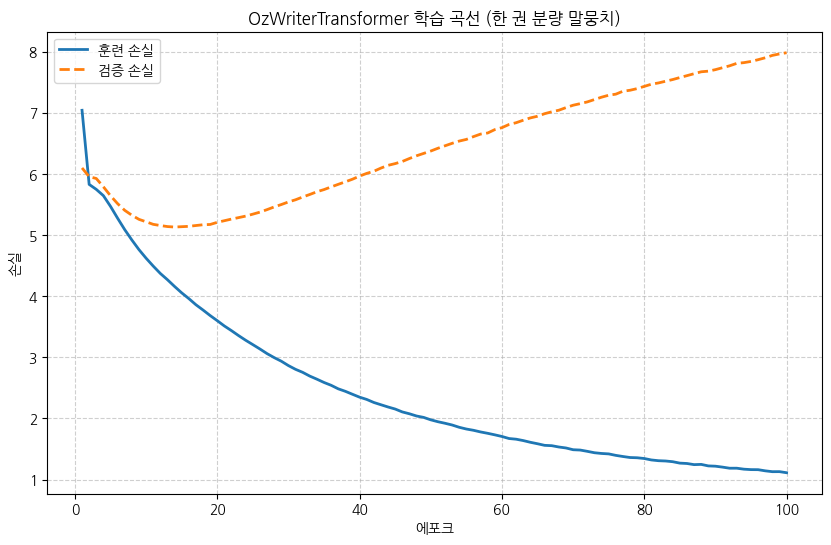

In [10]:
# 참고 - 학습 곡선 (EpochLogger 내장 plot, §7.7)
# 검증 손실이 20 에포크 부근에서 최저를 찍은 뒤 다시 상승한다.
history['log'].plot(
    title='OzWriterTransformer 학습 곡선 (한 권 분량 말뭉치)',
)

학습 곡선에서 검증 손실이 초기에 떨어지다가 다시 꾸준히 상승하는 패턴이
보인다. 한 권 분량의 작은 말뭉치에서 모델이 학습 데이터를 외워 가면서
검증 분포로부터 멀어지는 신호다.

## [코드 10-10] 탐욕 디코딩 생성 함수

매 단계 가장 높은 로짓의 토큰을 선택한다. `<eos>`를 학습하지 않았으므로
정해진 개수(`max_new_words`)만큼 생성한 뒤 멈춘다. 프롬프트가 같으면 결과도
항상 같다.

In [ ]:
###############################################################################
# 코드 10-10 - 탐욕 디코딩을 적용한 생성 함수
###############################################################################
def generate_greedy(model, prompt, vocab, seq_length,
                    max_new_words=10, device='cpu'):
    itos = {i: t for t, i in vocab.items()}
    model.eval()
    words_in = prompt.lower().split()
    input_ids = [vocab[w] for w in words_in if w in vocab]
    with torch.no_grad():
        for _ in range(max_new_words):
            # 최대 시퀀스 길이를 넘기면 앞부분을 잘라낸다.
            src = torch.tensor(
                input_ids[-seq_length:], dtype=torch.long
            ).unsqueeze(0).to(device)
            logits = model(src)             # (1, seq_length, vocab_size)
            # 마지막 위치의 최고 확률 토큰
            next_id = logits[0, -1, :].argmax().item()
            input_ids.append(next_id)
    return ' '.join(itos[i] for i in input_ids)

for prompt in ['dorothy looked at', 'in the middle of']:
    print(f'=== 탐욕 디코딩 / 프롬프트: {prompt!r} ===')
    print(generate_greedy(
        model, prompt, vocab, SEQ_LENGTH,
        max_new_words=10, device=device,
    ))
    print()

=== 탐욕 디코딩 / 프롬프트: 'dorothy looked at' ===
dorothy looked at her aunt em , and seeing the scarecrow said ,

=== 탐욕 디코딩 / 프롬프트: 'in the middle of' ===
in the middle of the water , looking very lonely and sad . what



## [코드 10-11] 온도 샘플링 생성 함수

`argmax` 대신 `torch.multinomial`로 확률 분포에서 샘플링한다. 로짓을
온도로 나눈 뒤 소프트맥스를 적용해 분포의 날카로움을 조절한다. 온도가
높을수록 의외성(다양성)이 늘고 문법 일관성은 흔들린다.

In [34]:
###############################################################################
# 코드 10-11 - 온도 샘플링을 적용한 생성 함수
###############################################################################
import torch.nn.functional as F

def generate_temperature(model, prompt, vocab, seq_length,
                         max_new_words=10, temperature=1.0,
                         device='cpu'):
    itos = {i: t for t, i in vocab.items()}
    model.eval()
    words_in = prompt.lower().split()
    input_ids = [vocab[w] for w in words_in if w in vocab]
    with torch.no_grad():
        for _ in range(max_new_words):
            src = torch.tensor(
                input_ids[-seq_length:], dtype=torch.long
            ).unsqueeze(0).to(device)
            logits = model(src)
            # temperature: 온도 샘플링의 온도 하이퍼파라미터
            # 온도로 로짓을 나눠 확률 분포의 날카로움을 조절
            scaled_logits = logits[0, -1, :] / temperature
            probs = F.softmax(scaled_logits, dim=-1)
            # 확률 분포에서 샘플링 (탐욕 디코딩과 달리 확률적으로 선택)
            next_id = torch.multinomial(probs, num_samples=1).item()
            input_ids.append(next_id)
    return ' '.join(itos[i] for i in input_ids)


# 세 가지 온도값으로 동일 프롬프트 생성
prompt = 'in the middle of'
torch.manual_seed(SEED)
for temperature in [0.5, 1.0, 1.5]:
    print(f'=== 온도 {temperature} ===')
    for _ in range(4):
        print(generate_temperature(
            model, prompt, vocab, SEQ_LENGTH,
            max_new_words=10, temperature=temperature, device=device,
        ))
    print()

=== 온도 0.5 ===
in the middle of the water , looking very lonely and sad . what
in the middle of the water , looking very lonely and sad . what
in the middle of the water , looking very lonely and sad . what
in the middle of the water , looking very lonely and sad . what

=== 온도 1.0 ===
in the middle of the water , looking very lonely and sad . what
in the middle of the water , even the woodman sharpened his ears and
in the middle of the water , looking very lonely and sad . what
in the middle of the water , looking very lonely and sad . what

=== 온도 1.5 ===
in the middle of the great throne room but they all with straw ,
in the middle of the water , seeing we think do and luscious fruits
in the middle of the water , looking very lonely and sad . what
in the middle of woodman himself room . that’s i want give a heart



## [코드 10-12] 빔 서치 생성 함수

매 단계 상위 `beam_width`개 후보를 유지하며 경로를 탐색하고, 누적 로그
확률이 가장 높은 시퀀스를 반환한다. 확률 곱셈 대신 로그 확률의 덧셈으로
누적해 수치적으로 안정적이다. 빔 너비 1은 탐욕 디코딩과 같다.

In [ ]:
###############################################################################
# 코드 10-12 - 빔 서치를 적용한 생성 함수
###############################################################################
def generate_beam_search(model, prompt, vocab, seq_length,
                         max_new_words=10, beam_width=3,
                         device='cpu'):
    itos = {i: t for t, i in vocab.items()}
    model.eval()
    words_in = prompt.lower().split()
    init_ids = [vocab[w] for w in words_in if w in vocab]

    # 빔: (누적 로그 확률, 프롬프트 + 지금까지 생성한 토큰 인덱스 리스트) 
    beams = [(0.0, init_ids)]
    with torch.no_grad():
        for _ in range(max_new_words):
            candidates = []
            for log_prob, ids in beams:
                src = torch.tensor(
                    ids[-seq_length:], dtype=torch.long
                ).unsqueeze(0).to(device)
                logits = model(src)
                log_probs = F.log_softmax(logits[0, -1, :], dim=-1)
                # 상위 beam_width 개 후보 선택
                topk_log_probs, topk_ids = log_probs.topk(beam_width)
                for lp, nid in zip(
                    topk_log_probs.tolist(), topk_ids.tolist(),
                ):
                    candidates.append((log_prob + lp, ids + [nid]))
            # 전체 후보 중 누적 로그 확률 상위 beam_width 개만 유지
            beams = sorted(
                candidates, key=lambda x: x[0], reverse=True,
            )[:beam_width]
    # 누적 로그 확률이 가장 높은 시퀀스 반환
    best_ids = beams[0][1]
    return ' '.join(itos[i] for i in best_ids)


# 세 가지 빔 너비로 비교
prompt = 'dorothy looked at'
for beam_width in [1, 3, 5]:
    print(f'=== 빔 너비 {beam_width} ===')
    print(generate_beam_search(
        model, prompt, vocab, SEQ_LENGTH,
        max_new_words=10, beam_width=beam_width, device=device,
    ))
    print()

=== 빔 너비 1 ===
dorothy looked at her aunt em , and seeing the scarecrow said ,

=== 빔 너비 3 ===
dorothy looked at her aunt em , and seeing her silver shoes she

=== 빔 너비 5 ===
dorothy looked at her aunt em , she was walking briskly toward the



## (실험) 빔 너비에 따라 결과가 갈리는 프롬프트 찾기

[코드 10-12]를 그대로 사용해, 말뭉치에서 자주 등장한 3단어 조합을 프롬프트로
넣고 빔 너비 1(= 탐욕 디코딩), 3, 5의 결과를 비교한다. 세 결과가 서로 다른
프롬프트를 모아 본문 예제로 쓸 후보를 고른다.


In [14]:
# 실험 - 빔 너비 1 / 3 / 5의 결과가 갈리는 프롬프트 탐색
from collections import Counter

# 말뭉치에서 자주 나온 3단어 조합을 프롬프트 후보로 사용 (구두점 제외)
trigram_counter = Counter(
    tuple(tokens[i:i + 3]) for i in range(len(tokens) - 3)
)
prompt_candidates = [
    ' '.join(trigram)
    for trigram, _ in trigram_counter.most_common(2000)
    if all(word.isalpha() for word in trigram)
][:120]

NEW_WORDS = 15
BEAM_WIDTHS = (1, 3, 5)

diverged = []
for candidate in prompt_candidates:
    generated = {
        width: generate_beam_search(
            model, candidate, vocab, SEQ_LENGTH,
            max_new_words=NEW_WORDS, beam_width=width, device=device,
        )
        for width in BEAM_WIDTHS
    }
    # 세 빔 너비의 결과가 모두 다른 프롬프트만 수집
    if len(set(generated.values())) == len(BEAM_WIDTHS):
        diverged.append((candidate, generated))

print(f'후보 프롬프트 {len(prompt_candidates)}개 중 '
      f'빔 너비 1 / 3 / 5 결과가 모두 다른 프롬프트: {len(diverged)}개')
print()
for candidate, generated in diverged[:5]:
    print(f'=== 프롬프트: {candidate!r} ===')
    for width in BEAM_WIDTHS:
        print(f'  빔 너비 {width}: {generated[width]}')
    print()

후보 프롬프트 120개 중 빔 너비 1 / 3 / 5 결과가 모두 다른 프롬프트: 29개

=== 프롬프트: 'back to kansas' ===
  빔 너비 1: back to kansas and aunt em , the scarecrow stuck on the ground her pick home and tried
  빔 너비 3: back to kansas and aunt em , the scarecrow stuck on the tin woodman badly dented on the
  빔 너비 5: back to kansas and aunt em , now that it is the country thickly covered with sharp rocks

=== 프롬프트: 'the winged monkeys' ===
  빔 너비 1: the winged monkeys all it was so long before the gate of the city . so , the
  빔 너비 3: the winged monkeys each before the other side of the end of the city , so that he
  빔 너비 5: the winged monkeys each before the end of their travels . what shall we do ? asked the

=== 프롬프트: 'said the tin' ===
  빔 너비 1: said the tin woodman , returned the scarecrow . if it is not know anything , and the
  빔 너비 3: said the tin woodman , returned the scarecrow . so they called the lion . and the scarecrow
  빔 너비 5: said the tin woodman , returned the scarecrow . when the tin woodman , retu

## (실험) [그림 10-6]에 대응하는 탐색 트리 추적

빔 서치가 탐욕 디코딩과 갈라지는 순간을 눈으로 보기 위해, 단계마다 살아남은
빔과 가지치기로 탈락한 후보를 누적 로그 확률과 함께 출력한다. [코드 10-12]의
루프에 출력 코드만 덧붙인 함수다.

`'i shall get'`이 [그림 10-6]과 같은 형태다. 1단계에서는 탐욕 디코딩이 고르는
`my`(-0.69)가 앞서지만, 2단계에서 `back to`(-1.52)가 `my new`(-1.64)를 앞질러
최종 경로가 뒤집힌다.


In [29]:
# 실험 - 빔 서치 탐색 트리 추적 (코드 10-12에 출력만 추가)
def trace_beam_search(model, prompt, vocab, seq_length,
                      max_new_words=3, beam_width=3, device='cpu'):
    model.eval()
    itos = {i: t for t, i in vocab.items()}
    init_ids = [vocab[w] for w in prompt.lower().split() if w in vocab]
    beams = [(0.0, init_ids)]
    with torch.no_grad():
        for step in range(max_new_words):
            candidates = []
            for log_prob, ids in beams:
                src = torch.tensor(
                    ids[-seq_length:], dtype=torch.long, device=device,
                ).unsqueeze(0)
                log_probs = F.log_softmax(model(src)[0, -1, :], dim=-1)
                topk_log_probs, topk_ids = log_probs.topk(beam_width)
                for lp, nid in zip(
                    topk_log_probs.tolist(), topk_ids.tolist(),
                ):
                    candidates.append((log_prob + lp, ids + [nid]))
            survivors = sorted(
                candidates, key=lambda x: x[0], reverse=True,
            )[:beam_width]
            survivor_ids = {id(c) for c in survivors}

            print(f'[{step + 1}단계] 후보 {len(candidates)}개 '
                  f'-> 상위 {beam_width}개 유지')
            for log_prob, ids in sorted(
                candidates, key=lambda x: x[0], reverse=True,
            ):
                mark = '유지' if any(
                    ids is s[1] for s in survivors
                ) else '탈락'
                text = ' '.join(itos[i] for i in ids[len(init_ids):])
                print(f'    {mark}  {log_prob:7.3f}  {text}')
            beams = survivors
            print()
    best_log_prob, best_ids = beams[0]
    print(f'최종 선택 (누적 로그 확률 {best_log_prob:.3f}): '
          f'{" ".join(itos[i] for i in best_ids)}')
    return beams


# [그림 10-6]과 같은 케이스 - 2단계에서 탐욕 경로가 뒤집힌다
TRACE_PROMPT = 'each one of'
print(f'프롬프트: {TRACE_PROMPT!r}')
print(f'탐욕 디코딩: '
      f'{generate_greedy(model, TRACE_PROMPT, vocab, SEQ_LENGTH, 15, device)}')
print()
trace_beam_search(
    model, TRACE_PROMPT, vocab, SEQ_LENGTH,
    max_new_words=3, beam_width=3, device=device,
)
print()
print('--- 같은 프롬프트, 15 단어 생성 ---')
for width in (1, 3, 5):
    print(f'빔 너비 {width}: '
          f'{generate_beam_search(model, TRACE_PROMPT, vocab, SEQ_LENGTH, 15, width, device)}')

프롬프트: 'each one of'
탐욕 디코딩: each one of them to be alive . the witch of the north kissed by the favorite color

[1단계] 후보 3개 -> 상위 3개 유지
    유지   -1.496  them
    유지   -1.648  you
    유지   -1.670  the

[2단계] 후보 9개 -> 상위 3개 유지
    유지   -1.659  you must
    유지   -2.141  them to
    유지   -2.447  the flowers
    탈락   -2.938  them ,
    탈락   -3.565  them at
    탈락   -3.624  the poppies
    탈락   -4.580  the other
    탈락   -7.652  you may
    탈락   -8.651  you have

[3단계] 후보 9개 -> 상위 3개 유지
    유지   -1.696  you must enter
    유지   -3.082  the flowers is
    유지   -3.344  them to be
    탈락   -3.361  the flowers had
    탈락   -4.064  them to do
    탈락   -4.840  them to pass
    탈락   -5.390  you must be
    탈락   -6.212  the flowers ,
    탈락   -7.163  you must sleep

최종 선택 (누적 로그 확률 -1.696): each one of you must enter

--- 같은 프롬프트, 15 단어 생성 ---
빔 너비 1: each one of them to be alive . the witch of the north kissed by the favorite color
빔 너비 3: each one of you must enter his presence alone , and he will 